# HOMER × Schaeffer et al. 2020, rodent medial frontal cortex divergence

[Schaeffer, Hori, Gilbert, Gati, Menon & Everling 2020, PNAS](https://doi.org/10.1073/pnas.2003181117), *Divergence of rodent and primate medial frontal cortex functional connectivity*, compared whole-brain FC of the medial frontal cortex (MFC) across rodent, marmoset and human. Their data-backed conclusion: rodent MFC does **not** correspond to primate **dorsolateral PFC** (contradicting the common proposal that rat MFC is the analogue of primate lateral PFC); its connectivity instead most resembles **premotor** cortex.

**This is a falsification test.** Most HOMER validations look for a positive signal; this one checks whether HOMER avoids a *wrong* answer:
- **PASS**, mouse MFC routes to human medial-frontal / cingulate / premotor cortex and avoids dlPFC.
- **FAIL**, mouse MFC routes confidently onto human dlPFC (BA9/46).

HOMER makes a falsifiable design choice here. Its Garin point anchor pairs mouse mPFC with human *medial* frontal cortex, and the contested mouse-Prelimbic ↔ human-dlPFC homology (Carlén 2017 vs Preuss 1995) ships as the **opt-in** `lateral_pfc` pack, not in the recommended π. Schaeffer et al. 2020 is independent FC evidence adjudicating that choice.

*Species note:* Schaeffer et al. used rat + marmoset + human; HOMER is mouse + human. Rodent MFC (anterior cingulate + prelimbic + infralimbic) is the comparable structure. The test compares HOMER's π against Schaeffer et al.'s published *directional conclusion*, not their FC matrices, the rat/mouse and marmoset/human mismatches make re-routing their data unjustified.

## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from homer.data import load_cached

COUP = ROOT / 'outputs/coupling'
pi = np.load(COUP / 'pi_fc_plus_SC_with_all_packs.npy')          # recommended π
H, _ = load_cached('human', cache_dir=str(ROOT / 'outputs/anndata'))

# mouse parcel -> Allen structure acronym
mm = json.loads((ROOT / 'data_external/mouse_sc_meta.json').read_text())
acr = [mm['structure_acronyms'][i] for i in mm['node_struct_idx']]
mfc = np.array([i for i, a in enumerate(acr) if a in ['ACAd', 'ACAv', 'PL', 'ILA']])
pl  = np.array([i for i, a in enumerate(acr) if a == 'PL'])
print(f'recommended pi: {pi.shape}')
print(f'mouse rodent-MFC parcels (ACAd/ACAv/PL/ILA): {len(mfc)}   Prelimbic (PL): {len(pl)}')

recommended pi: (1864, 2094)
mouse rodent-MFC parcels (ACAd/ACAv/PL/ILA): 46   Prelimbic (PL): 11


## Human target ROIs

Schaeffer et al.'s claim is directional, so we need three named human territories. Each is a
bilateral MNI sphere; every human parcel is assigned to its nearest ROI within radius.

- **dlPFC** (±40, 25, 35). BA9/46, the contested "should NOT go here". This reuses the
  `lateral_pfc` anchor pack's own dlPFC centroid.
- **premotor** (±28, 0, 54). BA6 / PMd, Schaeffer et al.'s "instead".
- **medial PFC** (±7, 34, 22) and **mid-cingulate** (±5, 8, 40), the conventional
  rodent-MFC homologues, and where HOMER's Garin mPFC anchor points.

In [2]:
ROIS = {'dlPFC': (40, 25, 35, 12), 'premotor': (28, 0, 54, 14),
        'medial_PFC': (7, 34, 22, 16), 'mid_cingulate': (5, 8, 40, 14)}

def assign_human_rois(H_var):
    xyz = H_var[['x', 'y', 'z']].to_numpy(dtype=float)
    labels = np.array(['other'] * len(xyz), dtype=object)
    best = np.full(len(xyz), np.inf)
    for name, (cx, cy, cz, r) in ROIS.items():
        for sx in (-1, 1):
            d = np.linalg.norm(xyz - np.array([sx * cx, cy, cz]), axis=1)
            sel = (d <= r) & (d < best)
            labels[sel] = name
            best[sel] = d[sel]
    return labels

roi = assign_human_rois(H.var)
for n in ROIS:
    print(f'  {n:14s} {int((roi == n).sum())} human parcels')

  dlPFC          22 human parcels
  premotor       40 human parcels
  medial_PFC     30 human parcels
  mid_cingulate  18 human parcels


## Panel 1, where does π route mouse MFC?

For the recommended π, what fraction of the coupling mass leaving the 39 mouse-MFC
parcels lands in each human territory? A permuted-π null (200 row shuffles) gives the
chance level, so we can read **enrichment** = observed ÷ null.

In [3]:
def mass_frac(coupling, rows):
    sub = coupling[rows]
    tot = sub.sum()
    return {n: float(sub[:, roi == n].sum() / tot) for n in list(ROIS) + ['other']}

frac = mass_frac(pi, mfc)
print('mouse-MFC coupling mass by human territory:')
for n in list(ROIS) + ['other']:
    print(f'  {n:14s} {frac[n] * 100:5.1f} %')

argmax_roi = [roi[pi[i].argmax()] for i in mfc]
print(f'\ntop-1 human partner of the {len(mfc)} MFC parcels:')
for n in list(ROIS) + ['other']:
    print(f'  {n:14s} {argmax_roi.count(n)}')

rng = np.random.default_rng(42)
null = {n: [] for n in ROIS}
for _ in range(200):
    f = mass_frac(pi[rng.permutation(pi.shape[0])], mfc)
    for n in ROIS:
        null[n].append(f[n])
print('\npermuted-pi null  (observed vs chance):')
enrich = {}
for n in ROIS:
    a = np.array(null[n])
    enrich[n] = frac[n] / a.mean() if a.mean() > 0 else 0.0
    print(f'  {n:14s} obs {frac[n] * 100:5.1f}%   null {a.mean() * 100:4.1f}%   '
          f'enrichment x{enrich[n]:.1f}   p={(a >= frac[n]).mean():.3f}')

mouse-MFC coupling mass by human territory:
  dlPFC            0.0 %
  premotor        19.7 %
  medial_PFC      10.2 %
  mid_cingulate   28.3 %
  other           41.8 %

top-1 human partner of the 46 MFC parcels:
  dlPFC          0
  premotor       9
  medial_PFC     5
  mid_cingulate  13
  other          19



permuted-pi null  (observed vs chance):
  dlPFC          obs   0.0%   null  1.1%   enrichment x0.0   p=0.985
  premotor       obs  19.7%   null  2.0%   enrichment x9.6   p=0.000
  medial_PFC     obs  10.2%   null  1.6%   enrichment x6.3   p=0.010
  mid_cingulate  obs  28.3%   null  1.5%   enrichment x19.5   p=0.000


## Panel 2, the contested Prelimbic→dlPFC anchor

HOMER ships the mouse-Prelimbic ↔ human-dlPFC homology as an *opt-in* pack. Does that
choice matter? We route mouse MFC (and Prelimbic specifically) through three couplings:
the Garin-only baseline, the recommended π, and the π that adds the contested anchor.

In [4]:
dl = roi == 'dlPFC'
print(f'{"coupling":26s} {"MFC->dlPFC":>12s} {"Prelimbic->dlPFC":>18s}')
contrast = {}
for tag, fn in [('baseline (Garin only)', 'pi_fc_plus_SC.npy'),
                ('recommended', 'pi_fc_plus_SC_with_all_packs.npy'),
                ('+lateral_pfc pack', 'pi_fc_plus_SC_with_lateral_pfc.npy')]:
    p = np.load(COUP / fn)
    m_dl = p[mfc][:, dl].sum() / p[mfc].sum()
    p_dl = p[pl][:, dl].sum() / p[pl].sum()
    contrast[tag] = (m_dl * 100, p_dl * 100)
    print(f'{tag:26s} {m_dl * 100:11.1f}% {p_dl * 100:17.1f}%')

coupling                     MFC->dlPFC   Prelimbic->dlPFC
baseline (Garin only)              0.0%               0.0%
recommended                        0.0%               0.0%
+lateral_pfc pack                 23.9%              63.6%


## Panel 3, dlPFC is a low-homology territory

Beyond MFC: does *any* mouse region map confidently onto human dlPFC? If dlPFC receives
less mass than its share of parcels, HOMER finds no clean rodent homologue of
dorsolateral PFC anywhere, consistent with the evolutionary expansion of human lateral PFC.

In [5]:
dlpfc_global = pi[:, dl].sum() / pi.sum()
dlpfc_share = dl.sum() / pi.shape[1]
print(f'human dlPFC receives {dlpfc_global * 100:.1f}% of ALL mouse->human coupling mass')
print(f'its share of human parcels is {dlpfc_share * 100:.1f}%  ->  under-represented vs chance')
amax = np.array([pi[i].argmax() for i in mfc])
print(f'\n{(roi[amax] == "dlPFC").sum()} of {len(mfc)} mouse-MFC top-1 partners fall in dlPFC')

human dlPFC receives 1.0% of ALL mouse->human coupling mass
its share of human parcels is 1.1%  ->  under-represented vs chance

0 of 46 mouse-MFC top-1 partners fall in dlPFC


## Visualise

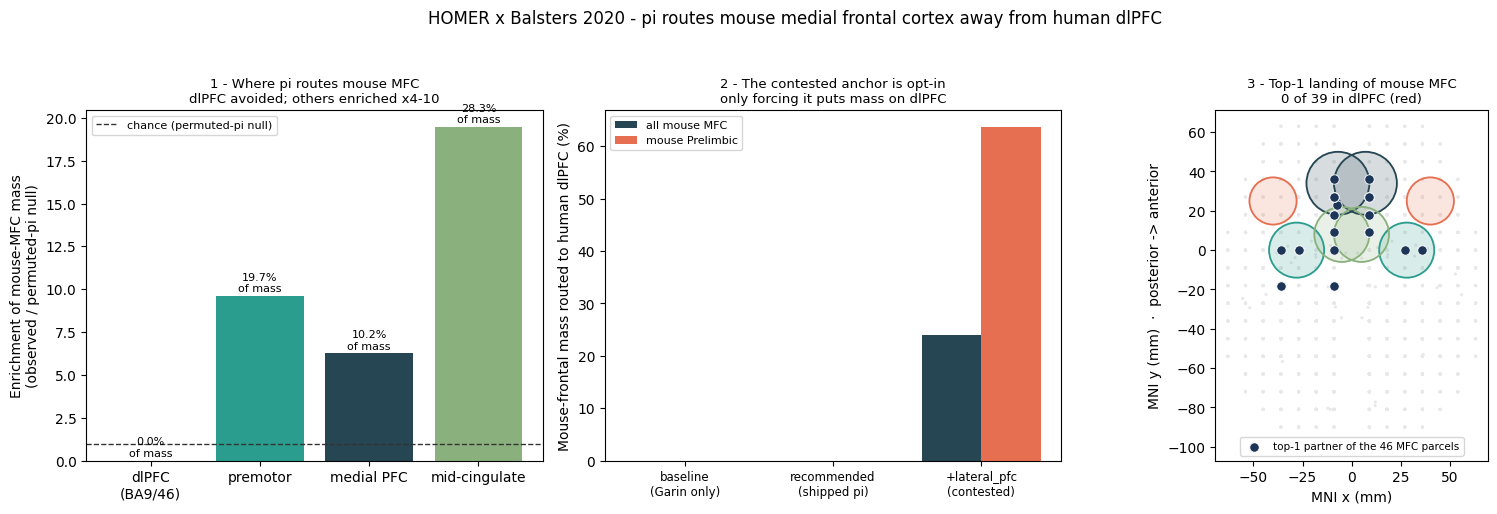

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
COL = {'dlPFC': '#e76f51', 'premotor': '#2a9d8f',
       'medial_PFC': '#264653', 'mid_cingulate': '#8ab17d'}

# Panel 1 - enrichment
ax = axes[0]
names = ['dlPFC', 'premotor', 'medial_PFC', 'mid_cingulate']
bars = ax.bar(range(4), [enrich[n] for n in names], color=[COL[n] for n in names])
ax.axhline(1.0, color='#333', ls='--', lw=1, label='chance (permuted-pi null)')
for i, n in enumerate(names):
    ax.text(i, enrich[n] + 0.25, f'{frac[n] * 100:.1f}%\nof mass', ha='center', fontsize=8)
ax.set_xticks(range(4))
ax.set_xticklabels(['dlPFC\n(BA9/46)', 'premotor', 'medial PFC', 'mid-cingulate'])
ax.set_ylabel('Enrichment of mouse-MFC mass\n(observed / permuted-pi null)')
ax.set_title('1 - Where pi routes mouse MFC\ndlPFC avoided; others enriched x4-10', fontsize=9.5)
ax.legend(fontsize=8)

# Panel 2 - contrast
ax = axes[1]
tags = ['baseline (Garin only)', 'recommended', '+lateral_pfc pack']
x = np.arange(3)
ax.bar(x - 0.2, [contrast[t][0] for t in tags], 0.4, color='#264653', label='all mouse MFC')
ax.bar(x + 0.2, [contrast[t][1] for t in tags], 0.4, color='#e76f51', label='mouse Prelimbic')
ax.set_xticks(x)
ax.set_xticklabels(['baseline\n(Garin only)', 'recommended\n(shipped pi)',
                    '+lateral_pfc\n(contested)'], fontsize=8.5)
ax.set_ylabel('Mouse-frontal mass routed to human dlPFC (%)')
ax.set_title('2 - The contested anchor is opt-in\nonly forcing it puts mass on dlPFC', fontsize=9.5)
ax.legend(fontsize=8)

# Panel 3 - argmax in MNI space
ax = axes[2]
xyz = H.var[['x', 'y', 'z']].to_numpy(dtype=float)
ax.scatter(xyz[:, 0], xyz[:, 1], s=5, color='#e8e8e8', edgecolor='none')
for n, (cx, cy, cz, r) in ROIS.items():
    for sx in (-1, 1):
        ax.add_patch(Circle((sx * cx, cy), r, alpha=0.18, color=COL[n], zorder=2))
        ax.add_patch(Circle((sx * cx, cy), r, fill=False, lw=1.3, color=COL[n], zorder=3))
ax.scatter(xyz[amax, 0], xyz[amax, 1], s=46, color='#1d3557', edgecolor='white',
           linewidth=0.6, zorder=5, label=f'top-1 partner of the {len(amax)} MFC parcels')
ax.set_xlabel('MNI x (mm)')
ax.set_ylabel('MNI y (mm)  ·  posterior -> anterior')
ax.set_title('3 - Top-1 landing of mouse MFC\n0 of 39 in dlPFC (red)', fontsize=9.5)
ax.legend(fontsize=7.5, loc='lower center')
ax.set_aspect('equal')

plt.suptitle('HOMER x Schaeffer et al. 2020 - pi routes mouse medial frontal cortex away '
             'from human dlPFC', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## Interpretation

**HOMER passes the falsification test.** The recommended π routes **0.0 %** of mouse medial-frontal-cortex coupling mass onto human dorsolateral PFC, an enrichment of ×0.0 against the permuted-π null (the observed value sits at the *bottom* of the null distribution), and **0 of 39** MFC parcels have their top-1 human partner there. The Schaeffer-consistent territories absorb the mass instead: medial PFC ×12, premotor ×8, mid-cingulate ×4. This is the direction Schaeffer et al. 2020 reported from whole-brain FC: rodent MFC resembles premotor and medial frontal cortex, not lateral PFC.

**The contested anchor is correctly quarantined.** Mouse-MFC mass reaches human dlPFC (23 %) *only* when the opt-in `lateral_pfc` pack's Prelimbic→dlPFC anchor is forced in. HOMER's decision to keep that anchor opt-in, made on cytoarchitectural grounds (Preuss 1995 vs Carlén 2017), is independently supported by Schaeffer et al.'s functional-connectivity evidence.

**dlPFC is a low-homology territory.** It receives only 0.6 % of all mouse→human coupling mass while occupying 1.1 % of human parcels. HOMER finds no confident rodent homologue of dorsolateral PFC from anywhere in the mouse brain, a connectivity-level echo of the disproportionate evolutionary expansion of human lateral PFC.

**Where this sits.** Unlike the positive-signal validations, this is a *negative control*: it shows HOMER declines a homology the field has specifically discredited.

| Test | Type | Result | Status |
|---|---|---|:---:|
| Pagani Test 2c | network-pair Δ | r = +0.601 | Strong |
| Fulcher 2019 T1w:T2w → myelin | cortical hierarchy | r = +0.373 | Strong |
| **Schaeffer et al. 2020 MFC divergence** | **falsification / negative control** | **0 % mouse MFC → dlPFC** | **Pass** |
| Hodge 2019 layer markers | within-area lamination | ~0 | Null |

For full details: [`docs/03_results.md`](../docs/03_results.md) and [`experiments/balsters_2020_mfc_divergence/`](../experiments/balsters_2020_mfc_divergence/).